In [122]:
from __future__ import annotations

import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

In [123]:
def build_env(slippery):
    env = gym.make("FrozenLake-v1",is_slippery=slippery,render_mode = "rgb_array",map_name = "8x8")
    env.reset()
    return env

In [124]:
def shape_rewards(env):
    desc = env.unwrapped.desc.flatten()
    P = env.unwrapped.P
    for state in P:
        for action in P[state]:           
            new_transitions = []
            for prob, next_state, old_reward, terminated in P[state][action]:
                tile_type = desc[next_state]
                if tile_type == b'H':
                    custom_reward = -1.0   
                elif tile_type == b'G':
                    custom_reward = 50.0    
                elif tile_type == b'S':
                    custom_reward = 0 
                else: 
                    custom_reward = -0.1
                new_transitions.append((prob, next_state, custom_reward, terminated))
            P[state][action] = new_transitions
    return env

In [125]:
def MonteCarlo(env: gym.Env, gamma, max_steps=100, n_itr=40000):
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    qvalues = np.zeros((n_states, n_actions, 2))
    policy = np.random.randint(0, n_actions, size=n_states)

    desc = env.unwrapped.desc.flatten()
    nonterminal = [s for s in range(n_states) if desc[s] not in (b'H', b'G')]

    episode_rewards = []
    episode_lengths = []

    for _ in range(n_itr):
        env.reset()
        state = np.random.choice(nonterminal)
        env.unwrapped.s = state
        action = np.random.randint(n_actions)
        trajectory = []
        total_reward = 0.0
        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            trajectory.append((state, action, reward))
            total_reward += reward
            if done:
                break
            state = next_state
            action = policy[state]

        episode_rewards.append(total_reward)
        episode_lengths.append(len(trajectory))

        G = 0.0
        visited = set()
        for state, action, reward in reversed(trajectory):
            G = reward + gamma * G
            if (state, action) not in visited:
                qvalues[state, action, 0] += G
                qvalues[state, action, 1] += 1
                visited.add((state, action))

        qvalue = qvalues[:, :, 0] / np.maximum(qvalues[:, :, 1], 1e-8)
        for state, _, _ in trajectory:
            policy[state] = np.argmax(qvalue[state])

    return policy, episode_rewards, episode_lengths

In [126]:

def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
    desc = np.asarray(env.unwrapped.desc, dtype=str)
    policy_grid = np.asarray(policy).reshape(desc.shape)
    arrows = np.array(["<", "v", ">", "^"])
    colors = {
        "S": "#9be7a1",
        "F": "#dceefb",
        "H": "#3a3a3a",
        "G": "#ffd54f",
    }

    fig, ax = plt.subplots(figsize=(8, 8))
    for r in range(desc.shape[0]):
        for c in range(desc.shape[1]):
            tile = desc[r, c]
            rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
            ax.add_patch(rect)

            if tile == "H":
                label = "H"
            elif tile == "G":
                label = "G"
            elif tile == "S":
                label = f"S{arrows[policy_grid[r, c]]}"
            else:
                label = arrows[policy_grid[r, c]]

            ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

    ax.set_xlim(0, desc.shape[1])
    ax.set_ylim(0, desc.shape[0])
    ax.set_xticks(np.arange(desc.shape[1] + 1))
    ax.set_yticks(np.arange(desc.shape[0] + 1))
    ax.grid(True, color="black", linewidth=1.0)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_aspect("equal")
    ax.set_title(title)
#    plt.savefig("plotforfrozenlake.png", dpi=300)
    plt.show()
    plt.close()

In [127]:
def main():
    gamma = 0.99
    env = build_env(slippery=False)
    shape_rewards(env)

    MCpolicy, episode_rewards, episode_lengths = MonteCarlo(env, gamma=gamma)

    plot_policy_on_frozen_lake(env, MCpolicy, title="MC Basic on FrozenLake 8x8")

    plt.figure()
    window = 200
    smoothed = np.convolve(episode_rewards, np.ones(window)/window, mode="valid")
    plt.plot(smoothed)
    plt.xlabel("Episode")
    plt.ylabel("Total reward")
    plt.title("Episode reward vs iteration")
    plt.show()

    plt.figure()
    smoothed = np.convolve(episode_lengths, np.ones(window)/window, mode="valid")
    plt.plot(smoothed)
    plt.xlabel("Episode")
    plt.ylabel("Episode length")
    plt.title("Episode length vs iteration")
    plt.show()

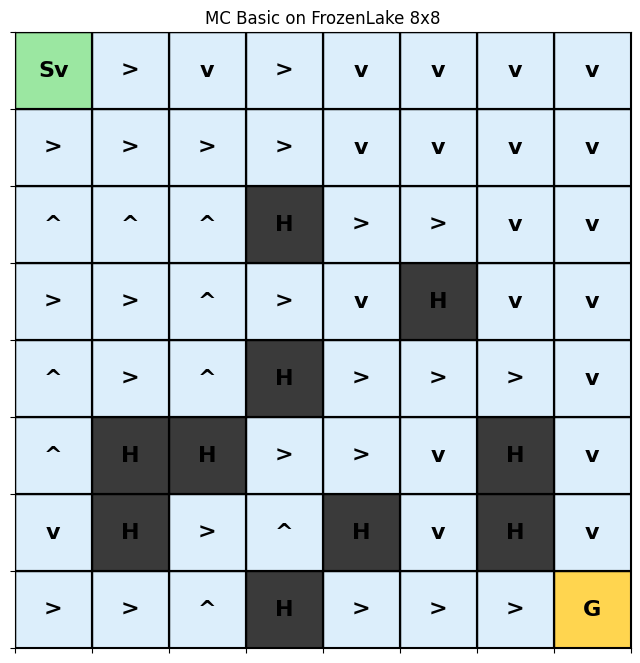

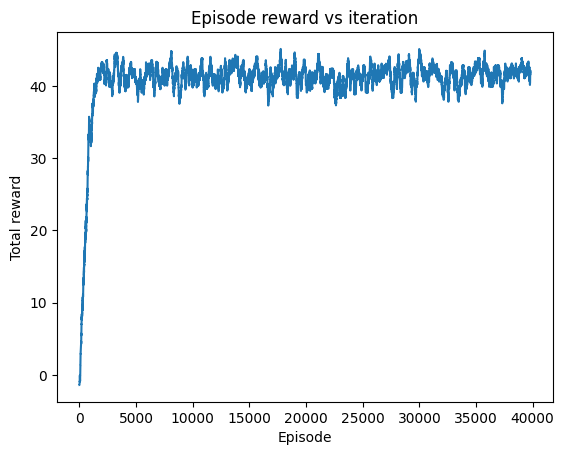

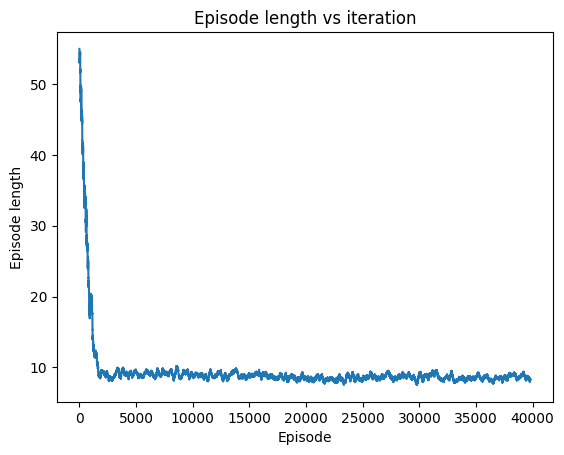

In [128]:
if __name__ == "__main__":
    main()